<a href="https://colab.research.google.com/github/Jhondev1l/degree2/blob/main/Trabalho_semana_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

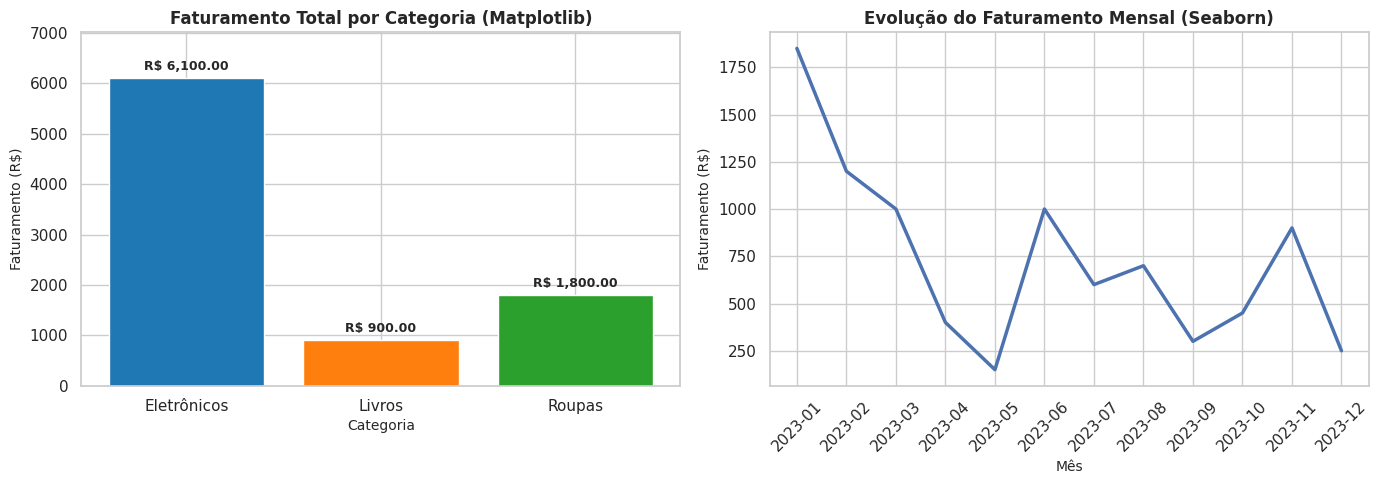

In [ ]:
import sqlite3

conexao = sqlite3.connect('dados_vendas.db')
cursor = conexao.cursor()
cursor.execute('''
CREATE TABLE IF NOT EXISTS vendas1 (
id_venda INTEGER PRIMARY KEY AUTOINCREMENT,
data_venda DATE,
produto TEXT,
categoria TEXT,
valor_venda REAL
)
''')
cursor.execute('''
INSERT INTO vendas1 (data_venda, produto, categoria, valor_venda) VALUES
('2023-01-01', 'Produto A', 'Eletrônicos', 1500.00),
('2023-01-05', 'Produto B', 'Roupas', 350.00),
('2023-02-10', 'Produto C', 'Eletrônicos', 1200.00),
('2023-03-15', 'Produto D', 'Livros', 200.00),
('2023-03-20', 'Produto E', 'Eletrônicos', 800.00),
('2023-04-02', 'Produto F', 'Roupas', 400.00),
('2023-05-05', 'Produto G', 'Livros', 150.00),
('2023-06-10', 'Produto H', 'Eletrônicos', 1000.00),
('2023-07-20', 'Produto I', 'Roupas', 600.00),
('2023-08-25', 'Produto J', 'Eletrônicos', 700.00),
('2023-09-30', 'Produto K', 'Livros', 300.00),
('2023-10-05', 'Produto L', 'Roupas', 450.00),
('2023-11-15', 'Produto M', 'Eletrônicos', 900.00),
('2023-12-20', 'Produto N', 'Livros', 250.00);
''')
conexao.commit()
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Carregando os dados
dados = [
    ('2023-01-01', 'Produto A', 'Eletrônicos', 1500.00),
    ('2023-01-05', 'Produto B', 'Roupas', 350.00),
    ('2023-02-10', 'Produto C', 'Eletrônicos', 1200.00),
    ('2023-03-15', 'Produto D', 'Livros', 200.00),
    ('2023-03-20', 'Produto E', 'Eletrônicos', 800.00),
    ('2023-04-02', 'Produto F', 'Roupas', 400.00),
    ('2023-05-05', 'Produto G', 'Livros', 150.00),
    ('2023-06-10', 'Produto H', 'Eletrônicos', 1000.00),
    ('2023-07-20', 'Produto I', 'Roupas', 600.00),
    ('2023-08-25', 'Produto J', 'Eletrônicos', 700.00),
    ('2023-09-30', 'Produto K', 'Livros', 300.00),
    ('2023-10-05', 'Produto L', 'Roupas', 450.00),
    ('2023-11-15', 'Produto M', 'Eletrônicos', 900.00),
    ('2023-12-20', 'Produto N', 'Livros', 250.00)
]

df = pd.DataFrame(dados, columns=['data_venda', 'produto', 'categoria', 'valor_venda'])
df['data_venda'] = pd.to_datetime(df['data_venda'])
df['mes'] = df['data_venda'].dt.strftime('%Y-%m')

#estilo visual geral
sns.set_theme(style='whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- GRÁFICO 1: Matplotlib  ---
faturamento_cat = df.groupby('categoria')['valor_venda'].sum().reset_index()
barras = ax1.bar(faturamento_cat['categoria'], faturamento_cat['valor_venda'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax1.set_title('Faturamento Total por Categoria (Matplotlib)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Categoria', fontsize=10)
ax1.set_ylabel('Faturamento (R$)', fontsize=10)

# Adicionando rótulos nas barras
for barra in barras:
    altura = barra.get_height()
    ax1.text(barra.get_x() + barra.get_width()/2., altura + 100,
             f'R$ {altura:,.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_ylim(0, faturamento_cat['valor_venda'].max() * 1.15)


# --- GRÁFICO 2: Seaborn  ---
faturamento_tempo = df.groupby('mes')['valor_venda'].sum().reset_index()
sns.lineplot(
    data=faturamento_tempo,
    x='mes',
    y='valor_venda',
    linewidth=2.5,
    ax=ax2
)
ax2.set_title('Evolução do Faturamento Mensal (Seaborn)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Mês', fontsize=10)
ax2.set_ylabel('Faturamento (R$)', fontsize=10)
ax2.tick_params(axis='x', rotation=45)


# Ajustes finais de layout
plt.tight_layout()
plt.show()